# Análisis Exploratorio de Datos (EDA)
## Reporte integrado para reconocimiento de actividad humana

**Proyecto Integrador - Avance 1**  
**Maestría en Inteligencia Artificial Aplicada**  
**Instituto Tecnológico y de Estudios Superiores de Monterrey**

| Integrante | Matrícula |
|---|---:|
| Isaura Yutsil Flores Escamilla | A01796552 |
| Paola Alejandra León Guarneros | A01796230 |
| Dylan Ulises Quiroz Hernández | A01796578 |

**Fecha:** 4 de octubre de 2026

---

## Resumen ejecutivo

Este análisis evalúa un conjunto multimodal de tareas de manejo manual compuesto por electromiografía de superficie (**sEMG**), captura de movimiento corporal completo (**Xsens MVN**), etiquetas temporales y variables antropométricas de **14 participantes**. El propósito de negocio y analítico es determinar si los datos tienen la calidad, cobertura y capacidad predictiva necesarias para construir un sistema de **reconocimiento de actividad humana (HAR)** y, de forma complementaria, estimar niveles de carga.

La evidencia del avance conduce a cinco decisiones principales:

| Pregunta de decisión | Conclusión ejecutiva | Evidencia principal |
|---|---|---|
| ¿El dataset está completo? | **Casi completo** | Falta una prueba del sujeto 12 en sEMG y MVNX. |
| ¿La calidad temporal es adecuada? | **Sí, dentro de cada archivo** | No se encontraron nulos, infinitos, retrocesos ni huecos relevantes. |
| ¿La frecuencia de muestreo es uniforme? | **No** | Varía aproximadamente entre 366.66 y 1005.65 Hz. |
| ¿La sEMG diferencia actividades? | **Distingue reposo de actividad** | Las clases activas presentan un solapamiento importante. |
| ¿La sEMG informa sobre la carga? | **Sí, de forma descriptiva** | La activación de clases como K y W aumenta cerca de tres veces entre 2 y 12 kg. |
| ¿Las modalidades están listas para fusionarse? | **No, sin alineación adicional** | Existen desfase de reloj y bases de frames distintas. |
| ¿Puede usarse una partición aleatoria? | **No** | La cohorte es pequeña y existe un efecto sujeto significativo. |

La primera meta realista es separar **reposo frente a actividad**. La clasificación detallada de actividades y la fusión sEMG-MVNX son viables, pero requieren curación reproducible, ventanas definidas en segundos, alineación multimodal por eventos y validación estricta en participantes no observados.

## Objetivos del análisis

### Objetivo general

Describir la estructura y calidad del conjunto de datos, extraer hallazgos que orienten el desarrollo de un modelo HAR y convertir esos hallazgos en decisiones técnicas trazables.

### Objetivos específicos

1. Verificar la integridad del diseño experimental y la correspondencia entre señales, etiquetas y archivos de movimiento.
2. Caracterizar a los participantes y resumir las propiedades de las series sEMG y MVNX.
3. Identificar valores faltantes, discontinuidades temporales, atípicos físicos e inconsistencias en las anotaciones.
4. Evaluar la cobertura y el desequilibrio de las siete clases de actividad.
5. Analizar la relación entre actividad muscular, clase y carga.
6. Definir un flujo de preprocesamiento y validación que evite sesgos y fuga de información.

### Contenido

1. [Introducción y descripción del conjunto de datos](#1-introducción-y-descripción-del-conjunto-de-datos)  
2. [Valores faltantes y patrones de ausencia](#2-valores-faltantes-y-patrones-de-ausencia)  
3. [Estadísticas resumidas](#3-estadísticas-resumidas)  
4. [Calidad temporal](#4-valores-faltantes-y-calidad-temporal)  
5. [Valores atípicos](#5-valores-atípicos)  
6. [Tendencias temporales](#6-tendencias-temporales)  
7. [Desequilibrio de las acciones etiquetadas](#7-desequilibrio-de-las-acciones-etiquetadas)  
8. [Preprocesamiento](#8-preprocesamiento)  
9. [Conclusiones](#9-conclusiones)  
10. [Referencias](#10-referencias)

## 1. Introducción y descripción del conjunto de datos

El presente trabajo desarrolla el análisis exploratorio del conjunto de datos de Bassani, Filippeschi y Avizzano (2021). El recurso contiene registros de **electromiografía de superficie (sEMG)** y captura de movimiento de cuerpo completo (**Xsens MVN**) de 14 sujetos sometidos a tareas de manejo manual. La intención es caracterizar la señal muscular, la ejecución cinemática y la calidad de las anotaciones antes de iniciar el modelado.

El nombre de cada archivo codifica sujeto, tarea, lado, carga y condición. El conjunto se organiza en cinco componentes:

| Carpeta o archivo | Contenido | Formato |
|---|---|---|
| `Data/Subj_XX/` | sEMG de 8 canales; un CSV por ensayo y lado cuando aplica | CSV |
| `Labels/Subj_XX/` | Segmentos de actividad y ventanas MVC sobre frames sEMG | CSV |
| `mvnx_files/Subj_XX/` | Captura Xsens de cuerpo completo; un archivo por ensayo | MVNX (XML) |
| `Subjs_info` | Demografía y antropometría de los 14 participantes | XLSX |
| `m_files/` | Scripts de MATLAB utilizados para filtrar y normalizar sEMG | `.m` |

Cada sujeto realiza un diseño de **37 ensayos**:

- **16 isocinéticos (`Isokin`)**: lado derecho/izquierdo, cargas de 2 y 4 kg y cuatro condiciones de ritmo.
- **9 MMH bimanuales (`MMH_Bim`)**: 2, 8 y 12 kg por tres repeticiones; existe un archivo sEMG por brazo.
- **12 MMH a una mano (`MMH_One`)**: lado izquierdo/derecho, 2 y 4 kg por tres repeticiones.

Se colocaron ocho canales en puntos estratégicos del cuerpo -muñecas, codos y rodillas-, por lo que cada registro sEMG contiene ocho series de actividad muscular. Las etiquetas describen siete clases:

| Código | Actividad | Código | Actividad |
|---|---|---|---|
| **N** | N-pose: de pie, reposo | **LT** | Levantar desde la mesa |
| **LF** | Levantar desde el piso | **W** | Caminar/transportar el peso |
| **K** | Mantener el objeto levantado | **PF** | Colocar en el piso |
| **PT** | Colocar en la mesa |  |  |

> **Control de consistencia documental:** el PDF menciona `50 bpm` en la descripción de los ensayos isocinéticos, mientras que el código técnico original define `60bpm`. Para conservar la trazabilidad, el código se mantiene sin modificaciones; antes de modelar debe contrastarse este punto con el protocolo y los nombres reales de archivo.

### 1.1 Preparación técnica

Las siguientes celdas conservan el código original de configuración, rutas, constantes y utilidades. Al ejecutarse desde `notebooks/`, localizan el repositorio, validan las rutas requeridas y crean un directorio de caché para los recorridos costosos.

In [1]:
from __future__ import annotations

import re
import time
import xml.etree.ElementTree as ET
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
ROOT = REPO_DIR / 'datos_unzipped'
EMG_DIR = ROOT / 'Data'
LABEL_DIR = ROOT / 'Labels'
LABEL2_DIR = ROOT / 'Labels 2'
MVNX_DIR = ROOT / 'mvnx_files'
MATLAB_DIR = ROOT / 'm_files'
SUBJ_XLSX = REPO_DIR / 'datos' / 'Subjs_info.xlsx'
CACHE_DIR = NOTEBOOK_DIR / '_cache'
CACHE_DIR.mkdir(exist_ok=True)
REFRESH = False  # Cambiar a True para reconstruir los caches costosos.

required_paths = [EMG_DIR, LABEL_DIR, LABEL2_DIR, MVNX_DIR, MATLAB_DIR, SUBJ_XLSX]
missing_paths = [path for path in required_paths if not path.exists()]
assert not missing_paths, f'Rutas no encontradas: {missing_paths}'

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [2]:
N_CHANNELS = 8
CHANNELS = range(1, N_CHANNELS + 1)
RAW_COLS = [f'Raw_V_{i}' for i in CHANNELS]
NORM_COLS = [f'Norm_V_{i}' for i in CHANNELS]
RMS_COLS = [f'Norm_RMS_{i}' for i in CHANNELS]
LABEL_ORDER = ['N', 'LF', 'K', 'PT', 'LT', 'W', 'PF']
LABEL_NAMES = {
    'N': 'Postura neutral', 'LF': 'Levantar desde el piso',
    'K': 'Mantener levantado', 'PT': 'Colocar en la mesa',
    'LT': 'Levantar desde la mesa', 'W': 'Caminar / cargar',
    'PF': 'Colocar en el piso',
}
LABEL_COLORS = dict(zip(
    LABEL_ORDER,
    ['#7f7f7f', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'],
))

def files_in(folder: Path) -> list[Path]:
    return sorted(path for path in folder.rglob('*') if path.is_file() and not path.name.startswith('.'))

def human_size(n_bytes: float) -> str:
    for unit in ('B', 'KB', 'MB', 'GB', 'TB'):
        if n_bytes < 1024 or unit == 'TB':
            return f'{n_bytes:.1f} {unit}'
        n_bytes /= 1024

def robust_outlier_mask(values: pd.Series, threshold: float = 3.5) -> pd.Series:
    median = values.median()
    mad = np.median(np.abs(values - median))
    if mad == 0:
        return pd.Series(False, index=values.index)
    modified_z = 0.6745 * (values - median) / mad
    return modified_z.abs() > threshold

### 1.2 Inventario de fuentes

El reporte documenta el siguiente inventario de referencia:

| Fuente | Archivos | Tamaño reportado | Contenido |
|---|---:|---:|---|
| Data | 679 CSV | 10.2 GB | Señales sEMG crudas y normalizadas de ocho canales |
| Labels | 679 CSV | 179.2 KB | Segmentos sobre frames sEMG y rangos MVC |
| Labels 2 | 517 CSV | 129.3 KB | Segmentos sobre frames MVNX |
| mvnx_files | 517 MVNX | 56.7 GB | Movimiento Xsens de cuerpo completo |
| Subjs_info | 1 XLSX | 9.4 KB | Demografía y antropometría |
| m_files | 2 MATLAB | 9.0 KB | Filtrado y normalización sEMG |

El inventario calculado a continuación permite confirmar esas cifras en el entorno local y anticipar el costo computacional de las etapas posteriores.

In [3]:
overview_rows = []
for item in sorted(ROOT.iterdir()):
    if item.name.startswith('.'):
        continue
    paths = files_in(item) if item.is_dir() else [item]
    overview_rows.append({
        'elemento': f'{item.name}/' if item.is_dir() else item.name,
        'subcarpetas': sum(child.is_dir() for child in item.iterdir()) if item.is_dir() else 0,
        'archivos': len(paths),
        'extensiones': pd.Series([path.suffix for path in paths]).value_counts().to_dict(),
        'tamaño': human_size(sum(path.stat().st_size for path in paths)),
        'ejemplo': paths[0].relative_to(item).as_posix() if item.is_dir() and paths else item.name,
    })

overview = pd.DataFrame(overview_rows)
display(overview)
print(f'Antropometría: {SUBJ_XLSX.name} ({human_size(SUBJ_XLSX.stat().st_size)})')

,elemento,subcarpetas,archivos,extensiones,tamaño,ejemplo
0,Data/,14,679,{'.csv': 679},10.2 GB,Subj_01/Subj_01_Isokin_L_02kg_40bpm_EMG_data.csv
1,Labels/,14,679,{'.csv': 679},179.2 KB,Subj_01/Subj_01_Isokin_L_02kg_40bpm_EMG_labels...
2,Labels 2/,14,517,{'.csv': 517},129.3 KB,Subj_01/Subj_01_Isokin_L_02kg_40bpm_mvnx_label...
3,m_files/,0,2,{'.m': 2},9.0 KB,EMG_processing.m
4,mvnx_files/,14,517,{'.mvnx': 517},52.8 GB,Subj_01/Subj_01_Isokin_L_02kg_40bpm.mvnx


Antropometría: Subjs_info.xlsx (9.4 KB)


### 1.3 Nomenclatura y correspondencia

La conversión de los nombres de archivo a columnas estructuradas evita asociaciones por texto parcial y permite auditar duplicados, emparejamientos y metadatos experimentales. La celda siguiente construye los catálogos sEMG y MVNX y verifica que cada señal tenga su archivo de etiquetas correspondiente.

In [4]:
EMG_RE = re.compile(
    r'Subj_(?P<subject>\d+)_(?:(?P<mvc>MVC)_)?(?P<task>Isokin|MMH_Bim|MMH_One|All)_(?P<side>[LR])'
    r'(?:_(?P<load_kg>\d+)kg_(?P<condition>St|\d+bpm|Trial_\d))?_EMG_data\.csv'
)
MVNX_RE = re.compile(
    r'Subj_(?P<subject>\d+)_(?P<task>Isokin|MMH_Bim|MMH_One)(?:_(?P<side>[LR]))?'
    r'_(?P<load_kg>\d+)kg_(?P<condition>St|\d+bpm|Trial_\d)\.mvnx'
)

def parse_files(paths: list[Path], pattern: re.Pattern) -> pd.DataFrame:
    records = []
    for path in paths:
        match = pattern.fullmatch(path.name)
        if match is None:
            raise ValueError(f'Nombre no reconocido: {path.name}')
        values = match.groupdict()
        records.append({
            'file': path.name, 'path': path, 'subject': int(values['subject']),
            'task': values['task'], 'side': values['side'],
            'is_mvc': values.get('mvc') is not None,
            'load_kg': float(values['load_kg']) if values['load_kg'] else np.nan,
            'condition': values['condition'], 'bytes': path.stat().st_size,
        })
    return pd.DataFrame(records)

emg = parse_files(files_in(EMG_DIR), EMG_RE)
emg['key'] = emg.file.str.replace('_EMG_data.csv', '', regex=False)
emg['label_path'] = [
    LABEL_DIR / f'Subj_{subject:02d}' / f"{key}_EMG_{'range' if is_mvc else 'labels'}.csv"
    for subject, key, is_mvc in zip(emg.subject, emg.key, emg.is_mvc)
]

mocap = parse_files(files_in(MVNX_DIR), MVNX_RE)
mocap['key'] = mocap.file.str.replace('.mvnx', '', regex=False)
mocap['label_path'] = [
    LABEL2_DIR / f'Subj_{subject:02d}' / f'{key}_mvnx_labels.csv'
    for subject, key in zip(mocap.subject, mocap.key)
]

pairing = pd.Series({
    'sEMG': len(emg), 'etiquetas_sEMG_encontradas': emg.label_path.map(Path.exists).sum(),
    'MVNX': len(mocap), 'etiquetas_MVNX_encontradas': mocap.label_path.map(Path.exists).sum(),
    'claves_sEMG_duplicadas': emg.key.duplicated().sum(),
    'claves_MVNX_duplicadas': mocap.key.duplicated().sum(),
})
display(pairing.to_frame('conteo'))
display(emg.groupby(['task', 'is_mvc']).size().rename('archivos').to_frame())

,conteo
sEMG,679
etiquetas_sEMG_encontradas,679
MVNX,517
etiquetas_MVNX_encontradas,517
claves_sEMG_duplicadas,0
claves_MVNX_duplicadas,0


archivos
task    is_mvc          
All     True          24
Isokin  False        223
        True           4
MMH_Bim False        252
        True           4
MMH_One False        168
        True           4

## 2. Valores faltantes y patrones de ausencia

La ausencia de datos se evaluó desde tres perspectivas: **archivos esperados**, **valores dentro de la señal** y **muestras sin etiquetar**.

### 2.1 Archivos faltantes

Se comparó la lista esperada de ensayos con los archivos observados. El reporte identifica la ausencia de `Isokin_L_02kg_80bpm` del **sujeto 12**, tanto en sEMG como en MVNX. Al faltar en ambas modalidades, se interpreta como una prueba no registrada y no como un error aislado de exportación. Los 679 archivos sEMG encontrados sí cuentan con su etiqueta correspondiente.

También existe heterogeneidad en los registros MVC: los sujetos 1 y 11 tienen un registro por tarea y lado -seis archivos-, mientras que el resto dispone de un único registro `ALL` por lado -dos archivos-. Esta diferencia debe quedar documentada porque afecta la comparabilidad de la normalización.

La siguiente celda reconstruye el diseño esperado y presenta las combinaciones ausentes por modalidad.

In [5]:
def expected_trials(with_bimanual_side: bool) -> pd.DataFrame:
    rows = []
    for side, load, condition in product('LR', (2, 4), ('St', '40bpm', '60bpm', '80bpm')):
        rows.append(('Isokin', side, float(load), condition))
    bimanual_sides = 'LR' if with_bimanual_side else [None]
    for side, load, trial in product(bimanual_sides, (2, 8, 12), (1, 2, 3)):
        rows.append(('MMH_Bim', side, float(load), f'Trial_{trial}'))
    for side, load, trial in product('LR', (2, 4), (1, 2, 3)):
        rows.append(('MMH_One', side, float(load), f'Trial_{trial}'))
    design = pd.DataFrame(rows, columns=['task', 'side', 'load_kg', 'condition'])
    return pd.concat([design.assign(subject=subject) for subject in range(1, 15)], ignore_index=True)

def find_missing(found: pd.DataFrame, expected: pd.DataFrame) -> pd.DataFrame:
    keys = ['subject', 'task', 'side', 'load_kg', 'condition']
    compared = expected.merge(found[keys], on=keys, how='left', indicator=True)
    return compared.loc[compared['_merge'].eq('left_only'), keys].reset_index(drop=True)

missing_emg = find_missing(emg.loc[~emg.is_mvc], expected_trials(True))
missing_mocap = find_missing(mocap, expected_trials(False))
print('Pruebas sEMG faltantes:')
display(missing_emg)
print('Pruebas MVNX faltantes:')
display(missing_mocap)

file_counts = pd.concat({
    'sEMG_pruebas': emg.loc[~emg.is_mvc].groupby(['subject', 'task']).size().unstack(fill_value=0),
    'sEMG_MVC': emg.loc[emg.is_mvc].groupby('subject').size().rename('MVC').to_frame(),
    'MVNX': mocap.groupby('subject').size().rename('MVNX').to_frame(),
}, axis=1)
display(file_counts)

Pruebas sEMG faltantes:


,subject,task,side,load_kg,condition
0,12,Isokin,L,2.0,80bpm


Pruebas MVNX faltantes:


,subject,task,side,load_kg,condition
0,12,Isokin,L,2.0,80bpm


sEMG_pruebas                 sEMG_MVC MVNX
              Isokin MMH_Bim MMH_One      MVC MVNX
subject                                           
1                 16      18      12        6   37
2                 16      18      12        2   37
3                 16      18      12        2   37
4                 16      18      12        2   37
5                 16      18      12        2   37
6                 16      18      12        2   37
7                 16      18      12        2   37
8                 16      18      12        2   37
9                 16      18      12        2   37
10                16      18      12        2   37
11                16      18      12        6   37
12                15      18      12        2   36
13                16      18      12        2   37
14                16      18      12        2   37

### 2.2 Valores faltantes dentro de la señal

El recorrido del avance no encontró valores `NaN`, huecos temporales ni clases faltantes o fuera del catálogo de siete etiquetas. Antes del escaneo intensivo, se verifica que los encabezados de todos los CSV correspondan al esquema esperado para ensayos y ventanas MVC. Después se calculan número de filas, duración y frecuencia efectiva a partir de los timestamps extremos.

> **Implicación:** no se anticipa una etapa de imputación numérica. La curación debe concentrarse en ausencias estructurales, calidad de anotaciones, atípicos físicos y armonización temporal.

In [6]:
EXPECTED_TRIAL_COLUMNS = ['Time'] + RAW_COLS + NORM_COLS + RMS_COLS
EXPECTED_MVC_COLUMNS = ['Time'] + RAW_COLS + [f'Rect_V_{i}' for i in CHANNELS]

schema_rows = []
for row in emg.itertuples():
    columns = pd.read_csv(row.path, nrows=0).columns.tolist()
    expected = EXPECTED_MVC_COLUMNS if row.is_mvc else EXPECTED_TRIAL_COLUMNS
    schema_rows.append({
        'file': row.file, 'is_mvc': row.is_mvc, 'n_columns': len(columns),
        'missing_columns': sorted(set(expected) - set(columns)),
        'extra_columns': sorted(set(columns) - set(expected)),
        'duplicated_columns': pd.Index(columns).duplicated().sum(),
    })
schema_check = pd.DataFrame(schema_rows)
schema_issues = schema_check.loc[
    schema_check.missing_columns.str.len().gt(0)
    | schema_check.extra_columns.str.len().gt(0)
    | schema_check.duplicated_columns.gt(0)
]
display(schema_check.groupby(['is_mvc', 'n_columns']).size().rename('archivos').to_frame())
display(schema_issues if not schema_issues.empty else 'Todos los encabezados cumplen el esquema esperado')

sample_trial = pd.read_csv(emg.loc[~emg.is_mvc, 'path'].iloc[0], nrows=5)
display(sample_trial)

,,archivos
is_mvc,n_columns,
False,25,643
True,17,36


'Todos los encabezados cumplen el esquema esperado'

,Time,Raw_V_1,Raw_V_2,Raw_V_3,Raw_V_4,Raw_V_5,Raw_V_6,Raw_V_7,Raw_V_8,Norm_V_1,Norm_V_2,Norm_V_3,Norm_V_4,Norm_V_5,Norm_V_6,Norm_V_7,Norm_V_8,Norm_RMS_1,Norm_RMS_2,Norm_RMS_3,Norm_RMS_4,Norm_RMS_5,Norm_RMS_6,Norm_RMS_7,Norm_RMS_8
0,1.593019e+12,0.001223,-0.001065,-0.000621,-0.001537,-0.006196,-0.005921,-0.000914,0.000681,17.691040,17.001839,13.438591,8.482910,16.136262,17.426007,6.710151,5.557895,12.031230,13.303838,9.677366,8.248461,15.235358,14.731584,4.319454,3.765478
1,1.593019e+12,0.001320,-0.000983,-0.000536,-0.001462,-0.006121,-0.005844,-0.000820,0.000767,26.465792,26.109491,21.746339,12.218660,21.183961,24.432992,11.996179,8.353080,12.005524,13.286225,9.644779,8.246330,15.221269,14.725230,4.305277,3.753772
2,1.593019e+12,0.001200,-0.001090,-0.000639,-0.001563,-0.006227,-0.005947,-0.000920,0.000663,19.690463,17.174237,16.696714,8.344966,11.000718,14.870009,9.384137,4.828935,11.996627,13.277828,9.620579,8.250362,15.218365,14.724095,4.294514,3.739711
3,1.593019e+12,0.001313,-0.001003,-0.000546,-0.001478,-0.006141,-0.005860,-0.000824,0.000753,14.843506,11.424742,12.686970,3.946905,2.465757,5.751889,6.728513,1.826411,11.972569,13.246604,9.587877,8.241496,15.204407,14.696499,4.281271,3.727109
4,1.593019e+12,0.001188,-0.001099,-0.000651,-0.001595,-0.006249,-0.005972,-0.000927,0.000652,6.763934,5.864310,6.384361,2.303998,6.725128,5.264261,3.409625,0.672404,11.937953,13.209473,9.554027,8.223991,15.175022,14.653860,4.264772,3.716906


In [7]:
def scan_csv_bounds(path: Path) -> tuple[int, float, float]:
    """Cuenta filas y lee timestamps extremos sin interpretar todas las columnas."""
    line_breaks = 0
    with path.open('rb') as handle:
        handle.readline()
        first = handle.readline()
        handle.seek(0)
        while chunk := handle.read(1 << 24):
            line_breaks += chunk.count(b'\n')
        handle.seek(max(0, path.stat().st_size - 4096))
        last = handle.read().strip().split(b'\n')[-1]
    return line_breaks - 1, float(first.split(b',')[0]), float(last.split(b',')[0])

SCAN_CACHE = CACHE_DIR / 'emg_scan.csv'
started = time.time()
if SCAN_CACHE.exists() and not REFRESH:
    emg_scan = pd.read_csv(SCAN_CACHE)
else:
    emg_scan = pd.DataFrame(
        [scan_csv_bounds(path) for path in emg.path],
        columns=['n_rows', 't0_ms', 't1_ms'],
    )
    emg_scan.insert(0, 'file', emg.file.to_numpy())
    emg_scan.to_csv(SCAN_CACHE, index=False)

emg = emg.merge(emg_scan, on='file', validate='one_to_one')
emg['duration_s'] = (emg.t1_ms - emg.t0_ms) / 1000
emg['fs_hz'] = (emg.n_rows - 1) / emg.duration_s
print(f'Escaneo resuelto en {time.time() - started:.1f} s')
print(f'{emg.n_rows.sum() / 1e6:.1f} millones de muestras; {emg.duration_s.sum() / 3600:.1f} h totales')
display(emg[['n_rows', 'duration_s', 'fs_hz']].describe(percentiles=[0.01, 0.5, 0.99]).round(2))

Escaneo resuelto en 0.0 s
27.7 millones de muestras; 13.2 h totales


,n_rows,duration_s,fs_hz
count,679.00,679.00,679.00
mean,40854.57,69.86,585.29
std,15403.00,16.69,156.61
min,9750.00,9.70,366.66
1%,15234.00,26.35,400.64
50%,37800.00,72.41,529.06
99%,90070.00,98.95,1002.94
max,103950.00,113.90,1005.65


### 2.3 Patrón de ausencia: muestras sin etiquetar

Debido a que el etiquetado fue manual, solo cerca de **dos tercios de cada grabación** está anotado. La ausencia se concentra al inicio y al final de los ensayos, posiblemente durante la preparación, el cierre o el reposicionamiento.

Los intervalos no anotados **no deben reasignarse automáticamente a la clase N**. Para entrenamiento supervisado se conservarán como desconocidos y se excluirán de la generación de ventanas. La cobertura y su distribución se cuantifican junto con el balance de clases en la sección 7.

## 3. Estadísticas resumidas

### 3.1 Participantes

La cohorte está conformada por **14 sujetos: 12 hombres y 2 mujeres**, con edades entre 25 y 38 años. Es una muestra pequeña y relativamente homogénea; por ello, cualquier correlación antropométrica debe interpretarse como descriptiva y no como evidencia causal o poblacional.

| Variable | Media | Desv. est. | Mín. | Mediana | Máx. |
|---|---:|---:|---:|---:|---:|
| Edad (años) | 30.6 | 4.6 | 25.0 | 28.0 | 38.0 |
| Masa corporal (kg) | 71.6 | 7.8 | 58.0 | 72.0 | 90.0 |
| Estatura (cm) | 178.6 | 5.4 | 166.0 | 179.0 | 187.0 |
| Longitud del pie (cm) | 29.3 | 1.8 | 25.0 | 29.8 | 32.0 |
| Altura del hombro (cm) | 148.7 | 5.0 | 140.0 | 148.5 | 156.0 |
| Ancho de hombros (cm) | 41.6 | 3.9 | 32.0 | 42.0 | 46.0 |
| Envergadura de codo (cm) | 88.8 | 5.9 | 76.0 | 90.5 | 96.0 |
| Envergadura de muñeca (cm) | 133.8 | 13.2 | 103.0 | 140.5 | 148.0 |
| Envergadura de brazo (cm) | 176.6 | 8.6 | 161.0 | 177.5 | 188.0 |
| Altura de cadera (cm) | 101.3 | 3.8 | 96.0 | 100.9 | 108.0 |
| Ancho de cadera (cm) | 32.6 | 2.4 | 28.0 | 33.0 | 37.0 |
| Altura de rodilla (cm) | 52.7 | 2.8 | 46.0 | 52.2 | 59.0 |
| Altura de tobillo (cm) | 13.6 | 2.0 | 10.0 | 13.5 | 17.0 |
| Grosor adicional de calzado | 2.1 | 1.9 | 1.0 | 1.5 | 8.0 |

Las celdas siguientes verifican tipos, duplicados y valores nulos; después identifican atípicos por IQR, generan distribuciones univariantes y construyen la matriz de correlación de Pearson.

In [8]:
participants = pd.read_excel(SUBJ_XLSX)
assert participants['ID'].is_unique, 'La columna ID contiene duplicados.'

participant_quality = pd.DataFrame({
    'dtype': participants.dtypes.astype(str),
    'nulos': participants.isna().sum(),
    'únicos': participants.nunique(dropna=False),
})
display(participant_quality)
display(participants.head())
display(participants['Sex'].value_counts(dropna=False).rename('sujetos').to_frame())
display(participants.describe(include='all').T)

,dtype,nulos,únicos
ID,int64,0,14
Sex,str,0,2
Age,int64,0,8
Body_mass,int64,0,9
Body_height,int64,0,10
Foot_length,float64,0,7
Shoulder_height,float64,0,11
Shoulder_width,int64,0,9
Elbow_span,float64,0,12
Wrist_span,float64,0,12


,ID,Sex,Age,Body_mass,Body_height,Foot_length,Shoulder_height,Shoulder_width,Elbow_span,Wrist_span,Arm_span,Hip_height,Hip_width,Knee_height,Ankle_height,Extra_shoe_thickeness
0,1,M,38,70,181,29.5,151.0,44,93.7,142.8,182,106.0,34.0,52.0,10,1
1,2,M,37,79,184,30.0,156.0,39,95.0,141.0,183,103.0,37.0,59.0,13,3
2,3,F,35,58,166,26.0,140.0,38,83.0,122.0,161,97.0,28.0,52.0,14,8
3,4,M,28,78,187,32.0,152.0,41,96.0,146.0,186,100.0,34.0,52.0,14,3
4,5,M,25,72,180,30.0,154.0,45,89.0,144.0,180,105.0,33.0,54.0,13,1


,sujetos
Sex,
M,12
F,2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,14.0,NaN,NaN,NaN,7.5,4.1833,1.0,4.25,7.5,10.75,14.0
Sex,14,2,M,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,14.0,NaN,NaN,NaN,30.571429,4.569368,25.0,27.0,28.0,34.75,38.0
Body_mass,14.0,NaN,NaN,NaN,71.571429,7.782765,58.0,68.5,72.0,72.75,90.0
Body_height,14.0,NaN,NaN,NaN,178.642857,5.372396,166.0,176.5,179.0,181.0,187.0
Foot_length,14.0,NaN,NaN,NaN,29.285714,1.80506,25.0,29.0,29.75,30.0,32.0
Shoulder_height,14.0,NaN,NaN,NaN,148.671429,4.992676,140.0,145.0,148.5,151.75,156.0
Shoulder_width,14.0,NaN,NaN,NaN,41.571429,3.916715,32.0,39.25,42.0,45.0,46.0
Elbow_span,14.0,NaN,NaN,NaN,88.835714,5.940164,76.0,84.25,90.5,93.275,96.0
Wrist_span,14.0,NaN,NaN,NaN,133.842857,13.249367,103.0,123.0,140.5,142.6,148.0


,ID,variable,valor,límite_inferior,límite_superior
0,3,Body_mass,58.0,62.125,79.125
1,11,Body_mass,60.0,62.125,79.125
2,13,Body_mass,90.0,62.125,79.125
3,3,Body_height,166.0,169.750,187.750
4,3,Foot_length,26.0,27.500,31.500
5,4,Foot_length,32.0,27.500,31.500
6,11,Foot_length,25.0,27.500,31.500
7,2,Knee_height,59.0,50.500,54.500
8,6,Knee_height,56.0,50.500,54.500
9,8,Knee_height,46.0,50.500,54.500


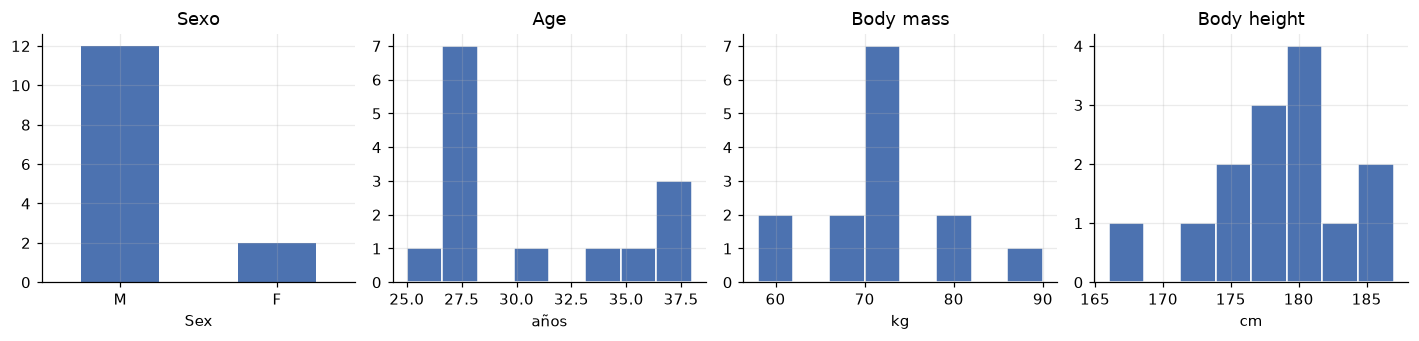

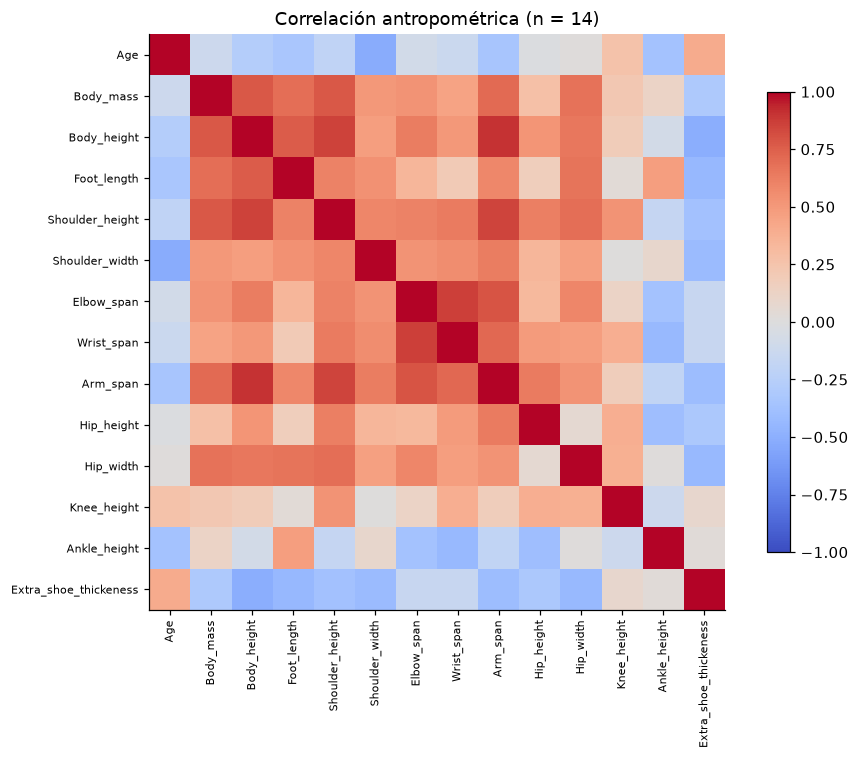

In [9]:
numeric_participants = participants.select_dtypes(include='number').drop(columns='ID')
iqr_rows = []
for column in numeric_participants:
    q1, q3 = numeric_participants[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = ~numeric_participants[column].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    for row_index in numeric_participants.index[mask]:
        iqr_rows.append({
            'ID': participants.loc[row_index, 'ID'],
            'variable': column,
            'valor': numeric_participants.loc[row_index, column],
            'límite_inferior': q1 - 1.5 * iqr,
            'límite_superior': q3 + 1.5 * iqr,
        })
participant_outliers = pd.DataFrame(iqr_rows)
display(participant_outliers if not participant_outliers.empty else 'Sin atípicos por IQR')

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
participants['Sex'].value_counts().plot.bar(ax=axes[0], rot=0, color='#4c72b0', title='Sexo')
for axis, column, unit in zip(axes[1:], ['Age', 'Body_mass', 'Body_height'], ['años', 'kg', 'cm']):
    axis.hist(participants[column], bins=8, color='#4c72b0', edgecolor='white')
    axis.set(title=column.replace('_', ' '), xlabel=unit)
fig.tight_layout()

correlation = numeric_participants.corr()
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap='coolwarm')
ax.set(xticks=range(len(correlation)), yticks=range(len(correlation)),
       xticklabels=correlation.columns, yticklabels=correlation.index,
       title='Correlación antropométrica (n = 14)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()

### 3.2 Registros sEMG

Los 679 archivos suman aproximadamente **27.7 millones de muestras** y **13.2 horas** de registro. La frecuencia no es constante: varía aproximadamente entre **366.66 y 1005.65 Hz**, con una mediana de 529.06 Hz. Esta dispersión obliga a definir ventanas en segundos y, cuando el algoritmo requiera matrices de longitud fija, remuestrear a una tasa común.

| Métrica | Media | Desv. est. | Mínimo | Mediana | Máximo |
|---|---:|---:|---:|---:|---:|
| Filas por archivo | 40,854.57 | 15,403.00 | 9,750 | 37,800 | 103,950 |
| Duración sEMG (s) | 69.86 | 16.69 | 9.70 | 72.41 | 113.90 |
| Frecuencia sEMG (Hz) | 585.29 | 156.61 | 366.66 | 529.06 | 1005.65 |
| Frames MVNX | 13,775.3 | 3,983.6 | 3,085 | 14,091 | 29,222 |
| Duración MVNX (s) | 57.4 | 16.6 | 12.9 | 58.7 | 121.8 |
| Tamaño MVNX (MB) | 109.7 | 31.2 | 24.8 | 112.3 | 226.8 |

La visualización siguiente muestra la variación de frecuencia por sujeto y la distribución de duración por tarea.

,min,median,max
subject,,,
1,690.4,813.5,931.5
2,503.0,524.9,546.8
3,518.7,540.4,596.1
4,388.0,455.9,490.1
5,366.7,427.4,470.4
6,473.7,516.0,554.9
7,475.6,510.8,538.5
8,505.1,532.5,557.5
9,466.1,510.7,550.2


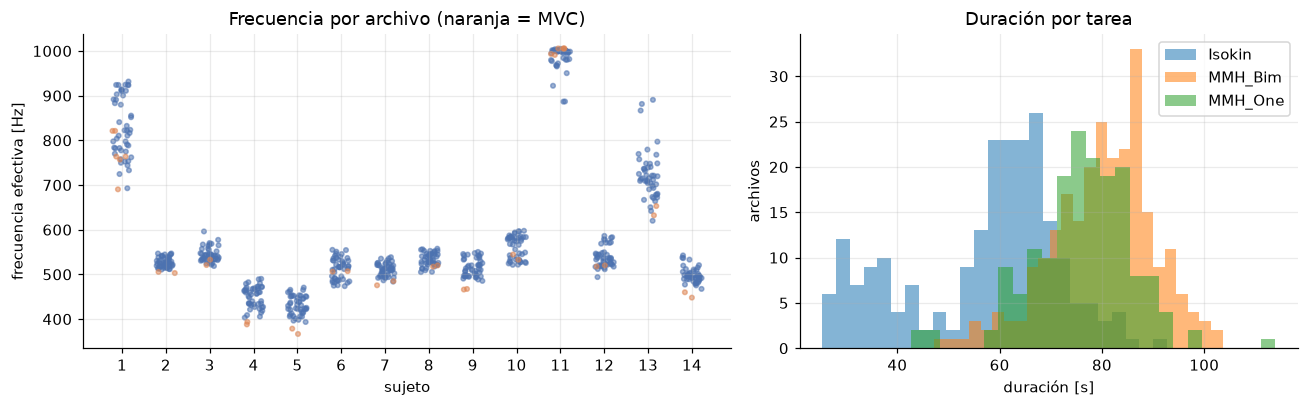

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={'width_ratios': [1.3, 1]})
rng = np.random.default_rng(42)
axes[0].scatter(
    emg.subject + rng.uniform(-0.22, 0.22, len(emg)), emg.fs_hz,
    c=np.where(emg.is_mvc, '#dd8452', '#4c72b0'), s=9, alpha=0.55,
)
axes[0].set(xlabel='sujeto', ylabel='frecuencia efectiva [Hz]',
            title='Frecuencia por archivo (naranja = MVC)', xticks=range(1, 15))
for task, group in emg.loc[~emg.is_mvc].groupby('task'):
    axes[1].hist(group.duration_s, bins=25, alpha=0.55, label=task)
axes[1].set(xlabel='duración [s]', ylabel='archivos', title='Duración por tarea')
axes[1].legend()
fig.tight_layout()

display(emg.groupby('subject').fs_hz.agg(['min', 'median', 'max']).round(1))

## 4. Valores faltantes y calidad temporal

El recorrido completo reportado no encontró valores nulos, infinitos, timestamps no monótonos, huecos temporales ni canales constantes. La variación relativa máxima del periodo fue **1.01 %**, compatible con redondeo.

La única ausencia estructural es la prueba completa del sujeto 12, que deberá excluirse de comparaciones que exijan un diseño balanceado. Dado que esta etapa recorre archivos de gran tamaño, el código usa cachés locales; `REFRESH = True` fuerza su reconstrucción.

In [11]:
FILE_STATS_CACHE = CACHE_DIR / 'emg_file_stats_v2.csv'
SEGMENT_STATS_CACHE = CACHE_DIR / 'emg_segment_stats_v2.csv'

def scan_emg_file(row) -> tuple[dict, list[dict]]:
    columns = ['Time'] + RAW_COLS + ([] if row.is_mvc else NORM_COLS + RMS_COLS)
    data = pd.read_csv(row.path, usecols=columns, dtype=np.float64)
    values = data.to_numpy()
    timestamps = data['Time'].to_numpy()
    dt = np.diff(timestamps)
    raw = data[RAW_COLS].to_numpy()
    dt_median = np.median(dt)

    stats = {
        'file': row.file,
        'n_nan': int(np.isnan(values).sum()),
        'n_inf': int(np.isinf(values).sum()),
        'dt_med_ms': dt_median, 'dt_min_ms': dt.min(), 'dt_max_ms': dt.max(),
        'n_gaps': int((dt > 1.5 * dt_median).sum()),
        'n_nonmono': int((dt <= 0).sum()),
        'n_constant_raw': int((raw.std(axis=0) == 0).sum()),
    }
    for channel, mean, std, peak in zip(CHANNELS, raw.mean(axis=0), raw.std(axis=0), np.abs(raw).max(axis=0)):
        stats.update({
            f'raw_mean_{channel}': mean, f'raw_std_{channel}': std,
            f'raw_absmax_{channel}': peak,
        })

    segment_rows = []
    if not row.is_mvc:
        rms = data[RMS_COLS].to_numpy()
        norm = data[NORM_COLS].to_numpy()
        for channel, p99, maximum in zip(CHANNELS, np.percentile(rms, 99, axis=0), norm.max(axis=0)):
            stats[f'rms_p99_{channel}'] = p99
            stats[f'normv_max_{channel}'] = maximum
        annotations = pd.read_csv(row.label_path)
        for start, end, label in annotations.itertuples(index=False):
            if end < start or start < 0 or end >= len(data):
                continue
            means = rms[start:end + 1].mean(axis=0)
            segment_rows.append({
                'file': row.file, 'Start_Frame': start, 'End_Frame': end, 'Label': label,
                **{f'rms_{channel}': value for channel, value in zip(CHANNELS, means)},
            })
    return stats, segment_rows

In [12]:
if FILE_STATS_CACHE.exists() and SEGMENT_STATS_CACHE.exists() and not REFRESH:
    file_stats = pd.read_csv(FILE_STATS_CACHE)
    segment_stats = pd.read_csv(SEGMENT_STATS_CACHE)
else:
    started = time.time()
    file_rows, segment_rows = [], []
    for index, row in enumerate(emg.itertuples(), start=1):
        file_result, segment_result = scan_emg_file(row)
        file_rows.append(file_result)
        segment_rows.extend(segment_result)
        if index % 100 == 0:
            print(f'{index}/{len(emg)} archivos; {time.time() - started:.0f} s')
    file_stats = pd.DataFrame(file_rows)
    segment_stats = pd.DataFrame(segment_rows)
    file_stats.to_csv(FILE_STATS_CACHE, index=False)
    segment_stats.to_csv(SEGMENT_STATS_CACHE, index=False)

file_stats = emg[['file', 'subject', 'task', 'side', 'load_kg', 'condition', 'is_mvc', 'fs_hz']].merge(
    file_stats, on='file', validate='one_to_one'
)
quality_summary = pd.Series({
    'nulos': file_stats.n_nan.sum(), 'infinitos': file_stats.n_inf.sum(),
    'timestamps_no_monótonos': file_stats.n_nonmono.sum(),
    'huecos_temporales': file_stats.n_gaps.sum(),
    'canales_raw_constantes': file_stats.n_constant_raw.sum(),
    'variación_relativa_máxima_dt': ((file_stats.dt_max_ms - file_stats.dt_min_ms) / file_stats.dt_med_ms).max(),
})
display(quality_summary.to_frame('valor'))
print('Dimensiones:', file_stats.shape, segment_stats.shape)

,valor
nulos,0.000000
infinitos,0.000000
timestamps_no_monótonos,0.000000
huecos_temporales,0.000000
canales_raw_constantes,0.000000
variación_relativa_máxima_dt,0.010111


Dimensiones: (679, 56) (10610, 12)


## 5. Valores atípicos

### 5.1 Atípicos en la amplitud sEMG

En un archivo típico, el pico absoluto de señal cruda es cercano a **15 mV** -mediana- y el 90 % de los archivos permanece por debajo de 34 mV. No obstante, el máximo alcanza **1951.7 mV**. Para distinguir ruido aislado de un fallo de canal se compara la desviación estándar del canal más ruidoso con la del canal típico del archivo.

| Archivo | Pico máximo (mV) | Std máxima (mV) | Tratamiento sugerido |
|---|---:|---:|---|
| `Subj_07_MMH_Bim_R_08kg_Trial_3` | 1951.7 | 739.8 | Excluir archivo |
| `Subj_07_MMH_Bim_R_12kg_Trial_1` | 1581.7 | 487.7 | Excluir archivo |
| `Subj_07_MMH_Bim_R_12kg_Trial_2` | 1849.5 | 194.3 | Excluir archivo |
| Archivos robustos adicionales | Hasta 150.7 | Hasta 23.3 | Inspección visual; conservar si el artefacto es aislado |

El patrón de los tres ensayos extremos es compatible con un electrodo o cable suelto y no con actividad muscular fisiológica. Se propone retirarlos temporalmente del conjunto de modelado, conservándolos en el manifiesto de exclusiones.

,absmax_mV,std_median_mV,std_max_mV
count,679.00,679.00,679.00
mean,26.92,1.12,4.06
std,119.27,0.89,34.72
min,3.60,0.10,0.18
50%,15.11,0.87,1.53
90%,33.99,2.25,3.71
99%,104.11,4.40,11.61
max,1951.68,7.82,739.81


,file,subject,task,side,absmax_mV,std_median_mV,std_max_mV,outlier_physical,outlier_robust
322,Subj_07_MMH_Bim_R_08kg_Trial_3_EMG_data.csv,7,MMH_Bim,R,1951.682925,2.468940,739.809012,True,True
323,Subj_07_MMH_Bim_R_12kg_Trial_1_EMG_data.csv,7,MMH_Bim,R,1581.658840,2.692175,487.654369,True,True
324,Subj_07_MMH_Bim_R_12kg_Trial_2_EMG_data.csv,7,MMH_Bim,R,1849.504352,4.416742,194.345213,True,True
303,Subj_07_Isokin_R_02kg_St_EMG_data.csv,7,Isokin,R,122.208312,5.676937,23.288809,False,True
337,Subj_07_MMH_One_R_04kg_Trial_3_EMG_data.csv,7,MMH_One,R,95.015720,4.389302,22.756000,False,True
300,Subj_07_Isokin_R_02kg_40bpm_EMG_data.csv,7,Isokin,R,150.730431,7.815231,19.830108,False,True


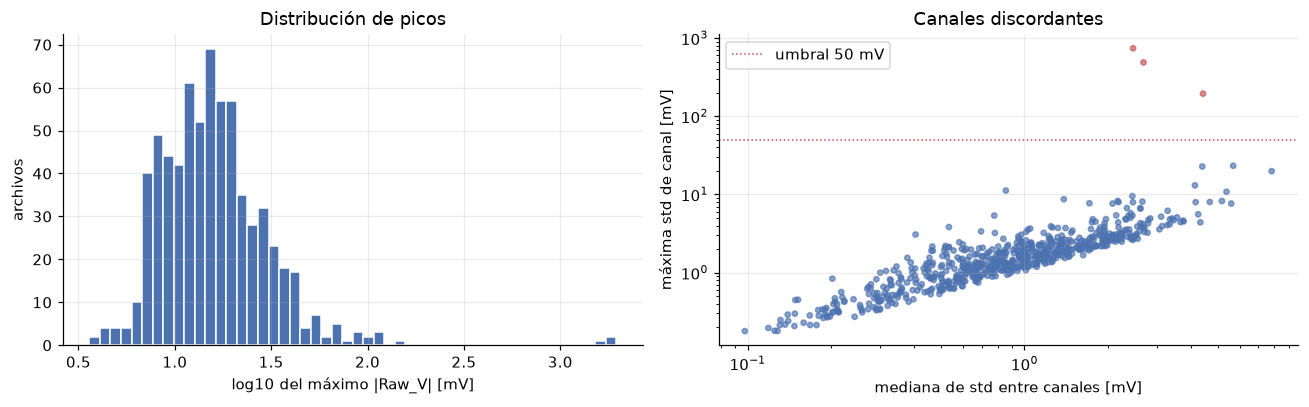

In [13]:
RAW_STD_COLUMNS = [f'raw_std_{channel}' for channel in CHANNELS]
RAW_MAX_COLUMNS = [f'raw_absmax_{channel}' for channel in CHANNELS]
file_stats['std_median_mV'] = file_stats[RAW_STD_COLUMNS].median(axis=1) * 1e3
file_stats['std_max_mV'] = file_stats[RAW_STD_COLUMNS].max(axis=1) * 1e3
file_stats['absmax_mV'] = file_stats[RAW_MAX_COLUMNS].max(axis=1) * 1e3
file_stats['outlier_physical'] = file_stats.std_max_mV > 50
file_stats['outlier_robust'] = robust_outlier_mask(np.log10(file_stats.std_max_mV.clip(lower=1e-9)))

outlier_files = file_stats.loc[
    file_stats.outlier_physical | file_stats.outlier_robust,
    ['file', 'subject', 'task', 'side', 'absmax_mV', 'std_median_mV', 'std_max_mV',
     'outlier_physical', 'outlier_robust'],
].sort_values('std_max_mV', ascending=False)
display(file_stats[['absmax_mV', 'std_median_mV', 'std_max_mV']].describe(percentiles=[0.5, 0.9, 0.99]).round(2))
display(outlier_files)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(np.log10(file_stats.absmax_mV.clip(lower=1e-9)), bins=50, color='#4c72b0', edgecolor='white')
axes[0].set(xlabel='log10 del máximo |Raw_V| [mV]', ylabel='archivos', title='Distribución de picos')
colors = np.where(file_stats.outlier_physical, '#c44e52', '#4c72b0')
axes[1].scatter(file_stats.std_median_mV, file_stats.std_max_mV, c=colors, s=12, alpha=0.65)
axes[1].set(xscale='log', yscale='log', xlabel='mediana de std entre canales [mV]',
            ylabel='máxima std de canal [mV]', title='Canales discordantes')
axes[1].axhline(50, color='#c44e52', linestyle=':', linewidth=1, label='umbral 50 mV')
axes[1].legend()
fig.tight_layout()

### 5.2 Valores atípicos en las anotaciones

Los archivos de etiquetas contienen inicio, fin y clase. Se esperaba un orden sin traslapes, pero el reporte identifica **11 segmentos inconsistentes en dos archivos**:

| Archivo | Problema | Tratamiento |
|---|---|---|
| `Subj_02_MMH_One_R_02kg_Trial_2` | Segmentos solapados y un segmento invertido | Excluir el ensayo hasta revisión manual |
| `Subj_05_Isokin_L_04kg_80bpm` | Segmento final de longitud cero | Eliminar el segmento tras revisión |

No es posible reconstruir de forma confiable la segmentación correcta sin contrastar la fuente original. Por ello, el análisis dependiente de etiquetas excluye archivos completos cuando encuentra una inconsistencia.

In [14]:
trials = emg.loc[~emg.is_mvc].copy()
label_tables = []
for row in trials.itertuples():
    table = pd.read_csv(row.label_path)
    table['file'] = row.file
    label_tables.append(table)
labels_emg = pd.concat(label_tables, ignore_index=True)
labels_emg = labels_emg.merge(
    trials[['file', 'subject', 'task', 'side', 'load_kg', 'condition', 'n_rows', 'fs_hz']],
    on='file', validate='many_to_one',
)
labels_emg['segment_id'] = labels_emg.groupby('file').cumcount()
labels_emg['segment_samples'] = labels_emg.End_Frame - labels_emg.Start_Frame + 1
labels_emg['segment_s'] = labels_emg.segment_samples / labels_emg.fs_hz
labels_emg['gap_to_next'] = labels_emg.groupby('file').Start_Frame.shift(-1) - labels_emg.End_Frame

invalid_labels = labels_emg.loc[
    labels_emg.Label.isna()
    | ~labels_emg.Label.isin(LABEL_ORDER)
    | labels_emg.segment_samples.le(0)
    | labels_emg.gap_to_next.lt(0)
    | labels_emg.Start_Frame.lt(0)
    | labels_emg.End_Frame.ge(labels_emg.n_rows)
]
duplicate_labels = labels_emg.duplicated(['file', 'Start_Frame', 'End_Frame', 'Label']).sum()
BAD_LABEL_FILES = set(invalid_labels.file)
valid_labels = labels_emg.loc[~labels_emg.file.isin(BAD_LABEL_FILES)].copy()

print(f'{len(labels_emg):,} segmentos en {labels_emg.file.nunique()} archivos')
print(f'Duplicados exactos: {duplicate_labels}; archivos con inconsistencias: {len(BAD_LABEL_FILES)}')
display(invalid_labels[['file', 'segment_id', 'Start_Frame', 'End_Frame', 'Label',
                        'segment_samples', 'gap_to_next']])

10,612 segmentos en 643 archivos
Duplicados exactos: 0; archivos con inconsistencias: 2


,file,segment_id,Start_Frame,End_Frame,Label,segment_samples,gap_to_next
1451,Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv,0,6941,7940,N,1000,-999.0
1452,Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv,1,6941,9083,LF,2143,-1141.0
1453,Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv,2,7942,10445,K,2504,-1360.0
1454,Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv,3,9085,11608,PT,2524,-1161.0
1455,Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv,4,10447,12953,N,2507,-1343.0
1456,Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv,5,11610,13822,LT,2213,-867.0
1457,Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv,6,12955,18656,W,5702,-4832.0
1459,Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv,8,18658,17905,N,-752,-1139.0
1460,Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv,9,16766,19169,LF,2404,-1262.0
1461,Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv,10,17907,20198,PT,2292,-1027.0


### 5.3 Valores por encima de 100 %MVC

Aunque `Norm_RMS` se expresa como porcentaje de la contracción voluntaria máxima, no debe interpretarse como una variable estrictamente acotada a 100. En el reporte, **434 de 640 pruebas válidas** superan 100 %MVC en el percentil 99 de algún canal; la mediana del p99 es 78.6 % y el p90 alcanza 170 %.

Como el fenómeno aparece en la mayoría de los archivos, no se trata como un atípico por sí mismo. Es más consistente con ventanas MVC de 2-5 s que subestiman la contracción máxima real. Los valores se conservarán, pero `%MVC` se tratará como escala relativa por sujeto y se complementará con escalamiento robusto.

In [15]:
BAD_SIGNAL_FILES = set(file_stats.loc[file_stats.outlier_physical, 'file'])
good_trials = file_stats.loc[~file_stats.is_mvc & ~file_stats.file.isin(BAD_SIGNAL_FILES)]
p99_columns = [f'rms_p99_{channel}' for channel in CHANNELS]
norm_max_columns = [f'normv_max_{channel}' for channel in CHANNELS]

p99_values = good_trials[p99_columns].stack()
norm_max_values = good_trials[norm_max_columns].stack()
print('Percentil 99 de Norm_RMS por archivo/canal [%MVC]')
display(p99_values.describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_frame('valor'))
print(f'Archivos con algún canal > 100 %MVC en p99: {(good_trials[p99_columns].max(axis=1) > 100).sum()} / {len(good_trials)}')
print(f'Norm_V máximo — mediana: {norm_max_values.median():.0f}, p99: {norm_max_values.quantile(0.99):.0f}, máximo: {norm_max_values.max():.0f} %MVC')

Percentil 99 de Norm_RMS por archivo/canal [%MVC]


,valor
count,5120.0
mean,95.2
std,74.7
min,6.1
50%,78.6
90%,170.2
99%,350.2
max,1581.8


Archivos con algún canal > 100 %MVC en p99: 434 / 640
Norm_V máximo — mediana: 394, p99: 4208, máximo: 13498 %MVC


## 6. Tendencias temporales

El dataset es esencialmente una colección de series de tiempo. La posición de cada segmento, la secuencia de acciones, la duración y la sincronización entre modalidades son parte de la señal predictiva.

### 6.1 Estructura temporal de cada ensayo

Las etiquetas siguen un guion experimental estable. En MMH, 210 de 252 ensayos bimanuales y 158 de 168 ensayos a una mano siguen la secuencia predominante:

`N → LF → K → PT → N → LT → W → PF → N → LF → PT → N → LT → W → PF → N → LF → PT → N`

Esta secuencia representa tres levantamientos desde el piso y dos desde la mesa, con `K` solo en el primero. En los ensayos isocinéticos se repite `N → LT → PT` cinco veces; la variante estática sigue `N → LT → K → PT → N`.

La celda siguiente resume las secuencias dominantes y estima las transiciones entre clases en tareas MMH.

,task,sequence,trials
0,Isokin,N LT PT N LT PT N LT PT N LT PT N LT PT N,140
1,Isokin,N LT K PT N,56
2,Isokin,N LT PT N LT PT N LT PT N LT PT N LT PT N LT PT N,15
3,MMH_Bim,N LF K PT N LT W PF N LF PT N LT W PF N LF PT N,210
4,MMH_Bim,N LF K PT N LT W PF N,16
5,MMH_Bim,N LF K PT N LT W PF N LF PT N LT W PF N,14
6,MMH_One,N LF K PT N LT W PF N LF PT N LT W PF N LF PT N,158
7,MMH_One,N LF K PT N LT W PF N,3
8,MMH_One,N LF K PT N LT W PF N LF PT N LT W PF N,3


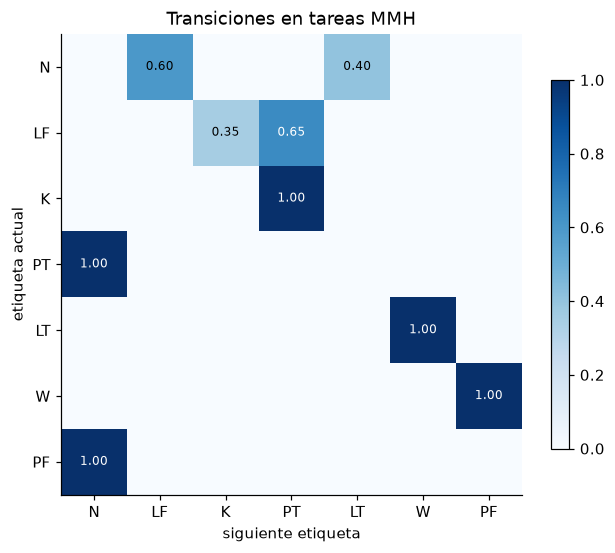

In [16]:
sequences = valid_labels.groupby(['task', 'file']).Label.apply(' '.join).rename('sequence').reset_index()
top_sequences = (
    sequences.groupby(['task', 'sequence']).size().rename('trials').reset_index()
    .sort_values(['task', 'trials'], ascending=[True, False])
    .groupby('task').head(3).reset_index(drop=True)
)
display(top_sequences)

mmh = valid_labels.loc[valid_labels.task.str.startswith('MMH')].copy()
mmh['next_label'] = mmh.groupby('file').Label.shift(-1)
transitions = pd.crosstab(mmh.Label, mmh.next_label).reindex(
    index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0
)
transitions = transitions.div(transitions.sum(axis=1), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(transitions, vmin=0, vmax=1, cmap='Blues')
ax.set(xticks=range(7), yticks=range(7), xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
       xlabel='siguiente etiqueta', ylabel='etiqueta actual', title='Transiciones en tareas MMH')
ax.grid(False)
for row, column in product(range(7), range(7)):
    value = transitions.iloc[row, column]
    if value > 0:
        ax.text(column, row, f'{value:.2f}', ha='center', va='center',
                color='white' if value > 0.6 else 'black', fontsize=8)
fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()

### 6.2 Dinámica de la señal dentro del ensayo

La envolvente `Norm_RMS` pasa aproximadamente de 5-10 %MVC en reposo a 50-100 % al levantar el objeto, permanece elevada durante `K` y `W` y disminuye en `N`. En ensayos isocinéticos, cada repetición `LT + PT` aparece como una ráfaga periódica asociada al ritmo del metrónomo.

La normalización incorporada en `Norm_V` y `Norm_RMS` reduce diferencias de escala entre canales y sujetos que, en voltaje crudo, pueden diferir un orden de magnitud. Por ello, `Norm_RMS` es la candidata inicial para una línea base, sin olvidar las limitaciones de la referencia MVC.

La siguiente celda reproduce el ejemplo de un ensayo bimanual y compara la correlación entre canales en señal cruda y normalizada.

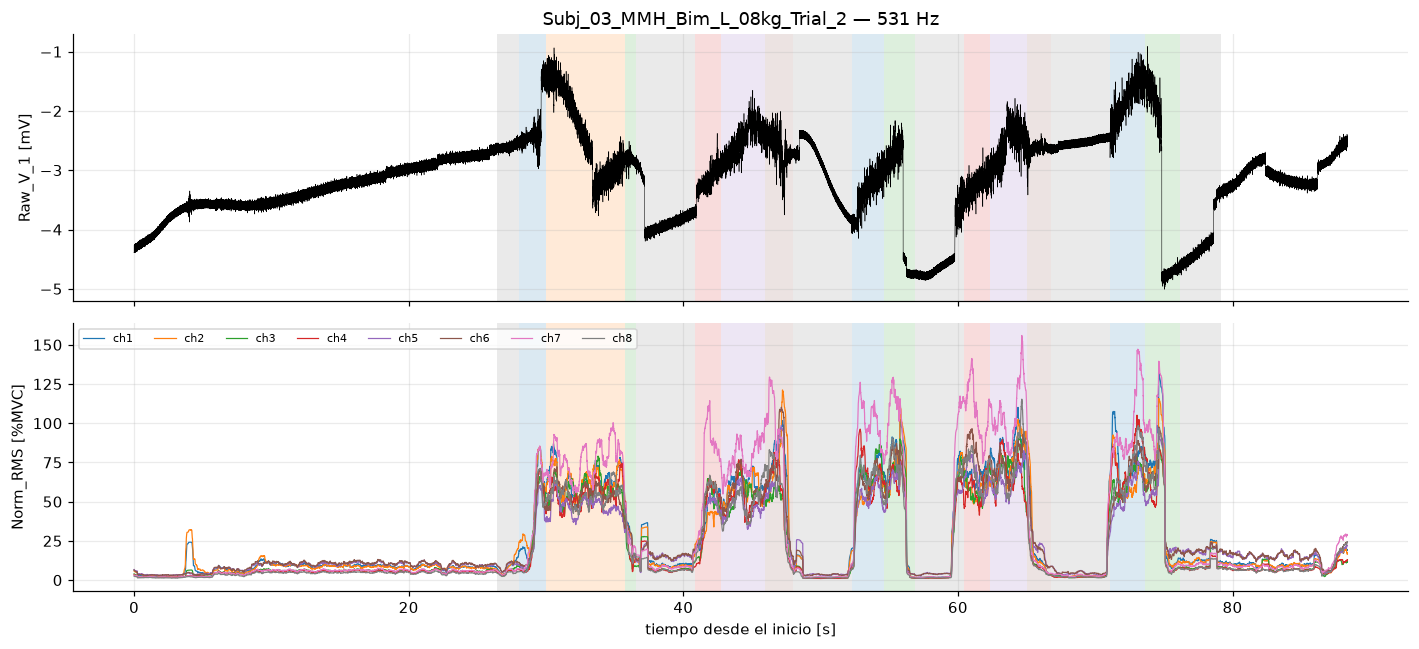

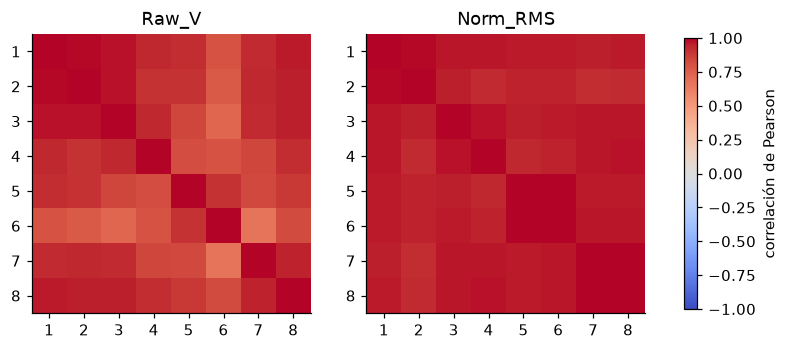

In [17]:
emg_by_key = emg.set_index('key')
EXAMPLE_KEY = 'Subj_03_MMH_Bim_L_08kg_Trial_2'
example_row = emg_by_key.loc[EXAMPLE_KEY]
example_data = pd.read_csv(example_row.path)
example_labels = pd.read_csv(example_row.label_path)
example_time = (example_data.Time - example_data.Time.iloc[0]) / 1000

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(example_time, example_data.Raw_V_1 * 1e3, color='black', linewidth=0.35)
axes[0].set(ylabel='Raw_V_1 [mV]', title=f'{EXAMPLE_KEY} — {example_row.fs_hz:.0f} Hz')
for column in RMS_COLS:
    axes[1].plot(example_time, example_data[column], linewidth=0.8, label=column.replace('Norm_RMS_', 'ch'))
for start, end, label in example_labels.itertuples(index=False):
    if end < start:
        continue
    end = min(end, len(example_time) - 1)
    for axis in axes:
        axis.axvspan(example_time.iloc[start], example_time.iloc[end], color=LABEL_COLORS[label], alpha=0.16, linewidth=0)
axes[1].set(xlabel='tiempo desde el inicio [s]', ylabel='Norm_RMS [%MVC]')
axes[1].legend(ncol=8, fontsize=7)
fig.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, columns, title in zip(axes, (RAW_COLS, RMS_COLS), ('Raw_V', 'Norm_RMS')):
    matrix = example_data[columns].corr()
    image = axis.imshow(matrix, vmin=-1, vmax=1, cmap='coolwarm')
    axis.set(xticks=range(8), yticks=range(8), xticklabels=range(1, 9), yticklabels=range(1, 9), title=title)
    axis.grid(False)
fig.colorbar(image, ax=axes, shrink=0.8, label='correlación de Pearson')

### 6.3 Sincronización entre modalidades

Los relojes sEMG y Xsens difieren cerca de **una hora** -mediana reportada de 3596.5 s-, con un residuo que varía aproximadamente de -22 a +33 s entre ensayos. Además, el registro sEMG dura en promedio 12 s más y cada modalidad usa una base de frames distinta.

En consecuencia, las modalidades **no deben fusionarse mediante una unión directa por timestamp**. La integración debe realizarse por ensayo usando etiquetas nativas y eventos compartidos -por ejemplo, el primer levantamiento, máximos de velocidad o cambios de postura- para estimar una alineación física.

Las siguientes celdas inspeccionan la estructura MVNX sin cargar cada XML completo, resumen frames, frecuencia y duración, y validan las etiquetas propias de esa modalidad.

In [18]:
MVNX_NAMESPACE = '{http://www.xsens.com/mvn/mvnx}'

def read_mvnx_header(path: Path) -> dict:
    header = {'segments': [], 'sensors': [], 'joints': [], 'ergonomic_angles': [], 'foot_contacts': []}
    plural = {
        'segment': 'segments', 'sensor': 'sensors', 'joint': 'joints',
        'ergonomicJointAngle': 'ergonomic_angles', 'contactDefinition': 'foot_contacts',
    }
    for event, element in ET.iterparse(path, events=('start', 'end')):
        tag = element.tag.replace(MVNX_NAMESPACE, '')
        if event == 'start' and tag == 'subject':
            header['subject'] = dict(element.attrib)
        elif event == 'end' and tag in plural and element.get('label'):
            header[plural[tag]].append(element.get('label'))
        elif event == 'end' and tag == 'frame' and element.get('type') == 'normal':
            header['first_frame'] = {
                child.tag.replace(MVNX_NAMESPACE, ''): np.fromstring(child.text, sep=' ')
                for child in element if child.text
            }
            header['first_frame_attributes'] = dict(element.attrib)
            return header
        if event == 'end' and tag in {'point', 'pos_b'}:
            element.clear()
    raise ValueError(f'No se encontró un frame normal en {path.name}')

example_mvnx = mocap.loc[mocap.task.eq('Isokin'), 'path'].iloc[0]
mvnx_header = read_mvnx_header(example_mvnx)
frame_lengths = pd.Series({name: len(values) for name, values in mvnx_header['first_frame'].items()})
print(example_mvnx.name)
print('Frecuencia declarada:', mvnx_header['subject']['frameRate'], 'Hz')
print('Segmentos:', len(mvnx_header['segments']), '| Sensores:', len(mvnx_header['sensors']), '| Articulaciones:', len(mvnx_header['joints']))
display(frame_lengths.rename('valores_por_frame').to_frame())

Subj_01_Isokin_L_02kg_40bpm.mvnx
Frecuencia declarada: 240 Hz
Segmentos: 23 | Sensores: 17 | Articulaciones: 22


,valores_por_frame
orientation,92
position,69
velocity,69
acceleration,69
angularVelocity,69
angularAcceleration,69
footContacts,4
sensorFreeAcceleration,51
sensorMagneticField,51
sensorOrientation,68


In [19]:
def scan_mvnx_bounds(path: Path) -> tuple[int, int, int, int]:
    with path.open('rb') as handle:
        head = handle.read(600_000).decode('utf-8', errors='ignore')
        handle.seek(max(0, path.stat().st_size - 40_000))
        tail = handle.read().decode('utf-8', errors='ignore')
    frame_rate = int(re.search(r'frameRate="(\d+)"', head).group(1))
    first_ms = int(re.search(r'index="0" tc="[^"]*" ms="(\d+)" type="normal"', head).group(1))
    last_index, last_ms = re.findall(
        r'index="(\d+)" tc="[^"]*" ms="(\d+)" type="normal"', tail
    )[-1]
    return frame_rate, int(last_index) + 1, first_ms, int(last_ms)

mvnx_stats = pd.DataFrame(
    [scan_mvnx_bounds(path) for path in mocap.path],
    columns=['frame_rate', 'n_frames', 'mvnx_t0_ms', 'mvnx_t1_ms'],
)
mocap = pd.concat([mocap.reset_index(drop=True), mvnx_stats], axis=1)
mocap['duration_s'] = mocap.n_frames / mocap.frame_rate
mocap['size_mb'] = mocap.bytes / 1e6
print('Frecuencias MVNX:', sorted(mocap.frame_rate.unique()))
print(f'Tamaño total: {mocap.size_mb.sum() / 1000:.1f} GB')
display(mocap[['n_frames', 'duration_s', 'size_mb']].describe().round(1))

Frecuencias MVNX: [np.int64(240)]
Tamaño total: 56.7 GB


,n_frames,duration_s,size_mb
count,517.0,517.0,517.0
mean,13775.3,57.4,109.7
std,3983.6,16.6,31.2
min,3085.0,12.9,24.8
25%,12166.0,50.7,97.6
50%,14091.0,58.7,112.3
75%,16039.0,66.8,127.1
max,29222.0,121.8,226.8


In [20]:
label2_tables = []
for row in mocap.itertuples():
    table = pd.read_csv(row.label_path)
    table['file'] = row.file
    table['subject'] = row.subject
    table['task'] = row.task
    table['n_frames'] = row.n_frames
    label2_tables.append(table)
labels_mvnx = pd.concat(label2_tables, ignore_index=True)
labels_mvnx['segment_frames'] = labels_mvnx.End_Frame - labels_mvnx.Start_Frame + 1
labels_mvnx['gap_to_next'] = labels_mvnx.groupby('file').Start_Frame.shift(-1) - labels_mvnx.End_Frame
invalid_mvnx_labels = labels_mvnx.loc[
    labels_mvnx.Label.isna() | ~labels_mvnx.Label.isin(LABEL_ORDER)
    | labels_mvnx.segment_frames.le(0) | labels_mvnx.gap_to_next.lt(0)
    | labels_mvnx.Start_Frame.lt(0) | labels_mvnx.End_Frame.ge(labels_mvnx.n_frames)
]
print(f'{len(labels_mvnx):,} segmentos MVNX; inconsistentes: {len(invalid_mvnx_labels)}')
display(labels_mvnx.groupby(['task', 'Label']).size().unstack(fill_value=0).reindex(columns=LABEL_ORDER, fill_value=0))
display(invalid_mvnx_labels)

8,337 segmentos MVNX; inconsistentes: 11


Label,N,LF,K,PT,LT,W,PF
task,,,,,,,
Isokin,1107,0,56,884,884,0,0
MMH_Bim,717,353,126,353,242,242,242
MMH_One,989,492,168,492,330,330,330


,Start_Frame,End_Frame,Label,file,subject,task,n_frames,segment_frames,gap_to_next
1122,525,981,N,Subj_02_MMH_One_R_02kg_Trial_2.mvnx,2,MMH_One,11195,457,-456.0
1123,525,1503,LF,Subj_02_MMH_One_R_02kg_Trial_2.mvnx,2,MMH_One,11195,979,-521.0
1124,982,2125,K,Subj_02_MMH_One_R_02kg_Trial_2.mvnx,2,MMH_One,11195,1144,-621.0
1125,1504,2656,PT,Subj_02_MMH_One_R_02kg_Trial_2.mvnx,2,MMH_One,11195,1153,-530.0
1126,2126,3270,N,Subj_02_MMH_One_R_02kg_Trial_2.mvnx,2,MMH_One,11195,1145,-613.0
1127,2657,3667,LT,Subj_02_MMH_One_R_02kg_Trial_2.mvnx,2,MMH_One,11195,1011,-396.0
1128,3271,5874,W,Subj_02_MMH_One_R_02kg_Trial_2.mvnx,2,MMH_One,11195,2604,-2206.0
1130,5875,5531,N,Subj_02_MMH_One_R_02kg_Trial_2.mvnx,2,MMH_One,11195,-343,-520.0
1131,5011,6108,LF,Subj_02_MMH_One_R_02kg_Trial_2.mvnx,2,MMH_One,11195,1098,-576.0
1132,5532,6578,PT,Subj_02_MMH_One_R_02kg_Trial_2.mvnx,2,MMH_One,11195,1047,-469.0


## 7. Desequilibrio de las acciones etiquetadas

La clase **N** domina tanto en número de segmentos como en tiempo anotado, que es la unidad relevante para un clasificador por ventanas.

| Clase | Segmentos | Horas | Duración mediana (s) | % del tiempo |
|---|---:|---:|---:|---:|
| N | 3,520 | 3.74 | 3.66 | 43.1 |
| LF | 1,196 | 0.84 | 2.43 | 9.7 |
| K | 475 | 0.73 | 4.40 | 8.5 |
| PT | 2,075 | 1.29 | 2.21 | 14.8 |
| LT | 1,692 | 0.79 | 1.65 | 9.1 |
| W | 813 | 0.67 | 2.97 | 7.7 |
| PF | 813 | 0.62 | 2.75 | 7.2 |

La categoría N concentra alrededor del 43 % del tiempo, frente a 7-15 % por clase activa: una razón aproximada de 6:1 entre mayoritaria y minoritaria. `K` contiene pocos segmentos porque aparece una sola vez en cada ensayo MMH, pero sus segmentos son los más largos.

El desequilibrio es moderado y debe tratarse con **F1 macro**, exactitud balanceada, métricas por clase y matriz de confusión. Durante el entrenamiento pueden emplearse ponderación de clases o submuestreo controlado de N; los conjuntos de validación y prueba deben conservar su distribución natural.

La celda siguiente calcula simultáneamente la cobertura de anotaciones y la distribución temporal de clases.

,segments,hours,median_duration_s,time_share_pct
Label,,,,
N,3520,3.74,3.66,43.05
LF,1196,0.84,2.43,9.71
K,475,0.73,4.40,8.45
PT,2075,1.29,2.21,14.81
LT,1692,0.79,1.65,9.13
W,813,0.67,2.97,7.70
PF,813,0.62,2.75,7.16


,labeled_fraction,lead_s,tail_s
count,641.00,641.00,641.00
mean,0.67,16.84,5.45
std,0.13,5.86,5.00
min,0.27,0.00,0.06
25%,0.62,13.75,2.67
50%,0.69,16.59,4.66
75%,0.75,20.26,6.83
max,0.99,38.75,50.14


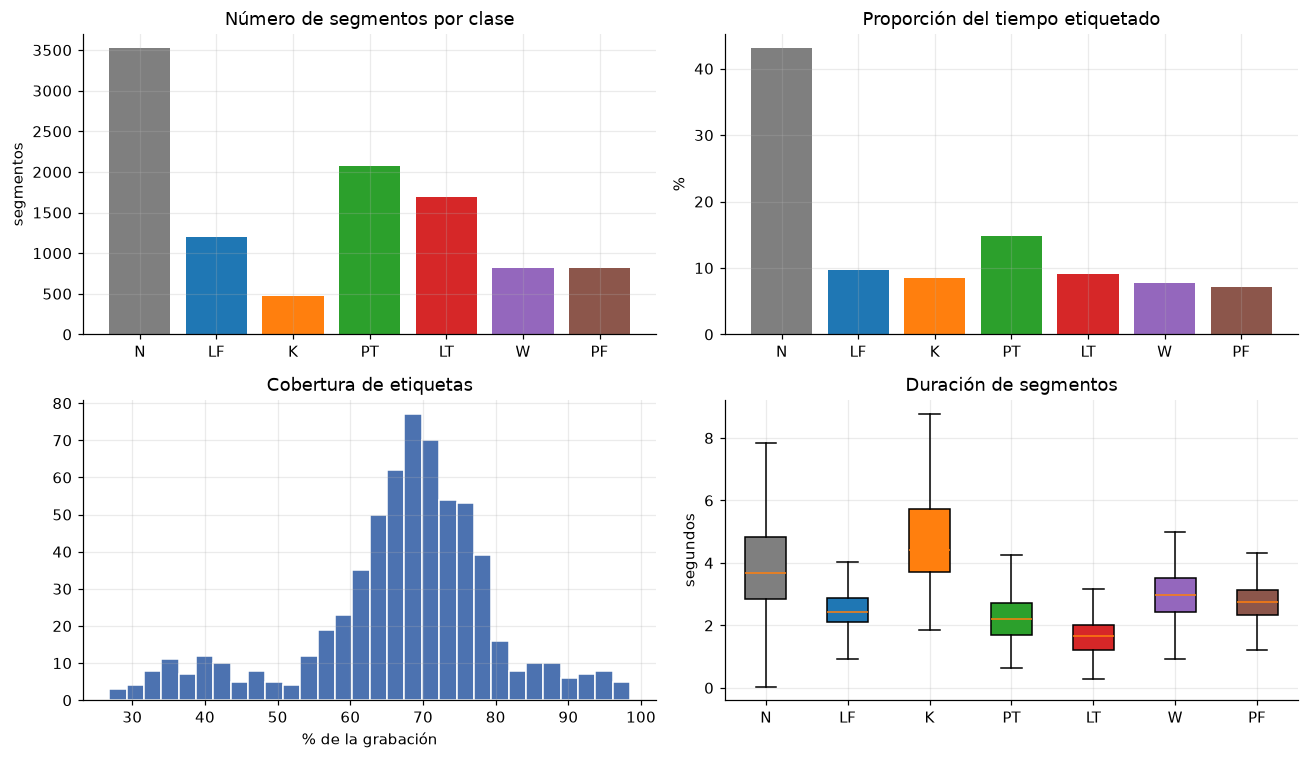

In [21]:
coverage = valid_labels.groupby('file').agg(
    first=('Start_Frame', 'min'), last=('End_Frame', 'max'),
    labeled=('segment_samples', 'sum'), n_rows=('n_rows', 'first'), fs_hz=('fs_hz', 'first'),
)
coverage['labeled_fraction'] = coverage.labeled / coverage.n_rows
coverage['lead_s'] = coverage['first'] / coverage.fs_hz
coverage['tail_s'] = (coverage.n_rows - coverage['last'] - 1) / coverage.fs_hz

time_by_class = valid_labels.groupby('Label').segment_s.sum().reindex(LABEL_ORDER)
class_summary = valid_labels.groupby('Label').agg(
    segments=('segment_id', 'size'),
    hours=('segment_s', lambda values: values.sum() / 3600),
    median_duration_s=('segment_s', 'median'),
).reindex(LABEL_ORDER)
class_summary['time_share_pct'] = 100 * class_summary.hours / class_summary.hours.sum()
display(class_summary.round(2))
display(coverage[['labeled_fraction', 'lead_s', 'tail_s']].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].bar(LABEL_ORDER, class_summary.segments, color=[LABEL_COLORS[label] for label in LABEL_ORDER])
axes[0, 0].set(title='Número de segmentos por clase', ylabel='segmentos')
axes[0, 1].bar(LABEL_ORDER, class_summary.time_share_pct, color=[LABEL_COLORS[label] for label in LABEL_ORDER])
axes[0, 1].set(title='Proporción del tiempo etiquetado', ylabel='%')
axes[1, 0].hist(coverage.labeled_fraction * 100, bins=30, color='#4c72b0', edgecolor='white')
axes[1, 0].set(title='Cobertura de etiquetas', xlabel='% de la grabación')
duration_data = [valid_labels.loc[valid_labels.Label.eq(label), 'segment_s'] for label in LABEL_ORDER]
boxes = axes[1, 1].boxplot(duration_data, tick_labels=LABEL_ORDER, patch_artist=True, showfliers=False)
for patch, label in zip(boxes['boxes'], LABEL_ORDER):
    patch.set_facecolor(LABEL_COLORS[label])
axes[1, 1].set(title='Duración de segmentos', ylabel='segundos')
fig.tight_layout()

### 7.1 Relación entre actividad, carga y sEMG

Se calculó el `Norm_RMS` medio de cada segmento válido. El reporte describe **10,527 segmentos válidos** y una separación fuerte entre reposo y actividad, pero débil entre clases activas debido al solapamiento de sus distribuciones.

La relación entre carga y activación es más consistente: en tareas MMH bimanuales, la media de `Norm_RMS` aumenta de forma monotónica al pasar de 2 a 8 y 12 kg. En `K` aumenta aproximadamente de 22.0 a 75.1 %MVC, y en `W` de 22.3 a 72.8 %MVC.

> **Lectura de negocio:** la sEMG aporta señal útil para distinguir reposo/actividad y estimar carga, pero la clasificación fina de actividades requerirá características temporales, información conjunta de canales y, posteriormente, cinemática MVNX.

load_kg,2.0,8.0,12.0
Label,,,
N,9.1,10.0,12.0
LF,20.0,37.0,49.9
K,22.0,52.6,75.1
PT,22.8,38.9,47.0
LT,18.8,32.3,45.0
W,22.3,51.3,72.8
PF,20.6,34.4,43.4


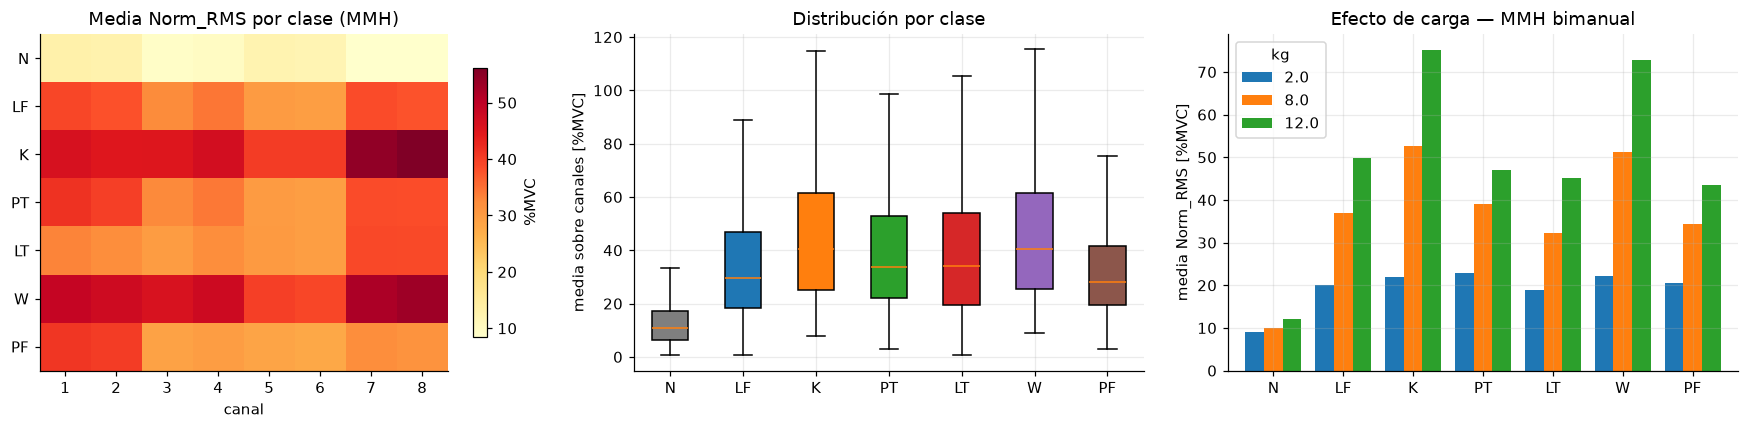

In [22]:
SEGMENT_RMS_COLUMNS = [f'rms_{channel}' for channel in CHANNELS]
segments = segment_stats.merge(
    trials[['file', 'subject', 'task', 'side', 'load_kg', 'condition']],
    on='file', validate='many_to_one',
)
segments = segments.loc[~segments.file.isin(BAD_SIGNAL_FILES | BAD_LABEL_FILES)].copy()
segments['rms_mean'] = segments[SEGMENT_RMS_COLUMNS].mean(axis=1)

class_channel_mean = (
    segments.loc[segments.task.str.startswith('MMH')]
    .groupby('Label')[SEGMENT_RMS_COLUMNS].mean().reindex(LABEL_ORDER)
)
load_effect = (
    segments.loc[segments.task.eq('MMH_Bim')]
    .groupby(['Label', 'load_kg']).rms_mean.mean().unstack().reindex(LABEL_ORDER)
)
display(load_effect.round(1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
image = axes[0].imshow(class_channel_mean, cmap='YlOrRd', aspect='auto')
axes[0].set(xticks=range(8), yticks=range(7), xticklabels=range(1, 9), yticklabels=LABEL_ORDER,
            xlabel='canal', title='Media Norm_RMS por clase (MMH)')
axes[0].grid(False)
fig.colorbar(image, ax=axes[0], shrink=0.8, label='%MVC')

class_data = [segments.loc[segments.Label.eq(label), 'rms_mean'] for label in LABEL_ORDER]
boxes = axes[1].boxplot(class_data, tick_labels=LABEL_ORDER, patch_artist=True, showfliers=False)
for patch, label in zip(boxes['boxes'], LABEL_ORDER):
    patch.set_facecolor(LABEL_COLORS[label])
axes[1].set(ylabel='media sobre canales [%MVC]', title='Distribución por clase')

load_effect.plot.bar(ax=axes[2], rot=0, width=0.8)
axes[2].set(xlabel='', ylabel='media Norm_RMS [%MVC]', title='Efecto de carga — MMH bimanual')
axes[2].legend(title='kg')
fig.tight_layout()

## 8. Preprocesamiento

Los controles anteriores indican que no se requiere imputación numérica, pero sí una **curación reproducible** antes del modelado. El flujo debe preservar la trazabilidad por sujeto, prueba y modalidad, y evitar que las decisiones de limpieza o particionado introduzcan sesgos o fuga de información.

### 8.1 Trazabilidad

- Documentar la prueba faltante del sujeto 12.
- Excluir o corregir contra la fuente original `Subj_02_MMH_One_R_02kg_Trial_2` y `Subj_05_Isokin_L_04kg_80bpm`.
- Mantener los intervalos no anotados como desconocidos.
- Retirar temporalmente los tres ensayos extremos del sujeto 7.
- Conservar un manifiesto versionado de exclusiones y una copia previa a cada transformación.

### 8.2 Transformación y homogeneización de la señal

Para la primera línea base se utilizará `Norm_RMS`. Si se reconstruyen características desde `Raw_V`, se reproducirá el procedimiento documentado por los autores, incluido el filtro notch Butterworth de 49-51 Hz.

Las ventanas se definirán en **segundos**. Las señales se remuestrearán a una frecuencia común cuando el algoritmo requiera longitudes fijas. MVNX opera a 240 Hz y se alineará mediante etiquetas nativas o eventos equivalentes, no mediante una unión directa por timestamp.

### 8.3 Segmentación y selección de variables

- Limitar la segmentación a intervalos con etiquetas válidas.
- Expresar duración y solapamiento en segundos.
- Impedir que una ventana atraviese una transición de clase.
- Usar `Norm_RMS` o características temporales por canal como predictores.
- Conservar archivo, timestamp e índice de frame solo para trazabilidad.
- Mantener sujeto, tarea, lado, carga y condición como metadatos de agrupación y auditoría, no como predictores por defecto.

### 8.4 Particionado y control del desequilibrio

La separación de entrenamiento, validación y prueba se realizará **por sujeto**, mediante `GroupKFold` o validación *leave-one-subject-out*. Una partición aleatoria por filas o ventanas causaría fuga de información porque observaciones altamente correlacionadas de la misma persona podrían aparecer en entrenamiento y prueba.

Todo escalamiento robusto, selección de variables o ajuste de umbrales se estimará únicamente con el conjunto de entrenamiento. La ponderación de clases o el submuestreo se aplicarán dentro de cada partición de entrenamiento, sin alterar los conjuntos de evaluación.

La siguiente celda inspecciona los scripts MATLAB de referencia para localizar las operaciones de filtrado, rectificación, RMS y normalización MVC empleadas por los autores.

In [23]:
PROCESSING_TERMS = re.compile(r'notch|butter|bandpass|highpass|lowpass|filter|mov|rms|rect|mvc', re.IGNORECASE)
for script_path in files_in(MATLAB_DIR):
    lines = script_path.read_text(encoding='utf-8', errors='replace').splitlines()
    relevant = [f'{line_number:>3}: {line}' for line_number, line in enumerate(lines, start=1) if PROCESSING_TERMS.search(line)]
    print(f'=== {script_path.name} ({len(lines)} líneas) ===')
    print('\n'.join(relevant) if relevant else 'Sin coincidencias')
    print()

=== EMG_processing.m (107 líneas) ===
 34:                     elseif file_name(9:11) == "MVC"
 37:                             mvc_labels_name = [file_name(1:22),'range.csv'];
 38:                             mvc_labels_dir = fullfile(basepath_EMGlabels,subject_num,mvc_labels_name);
 43:                                 mvc_labels_name = [file_name(1:25),'range.csv'];
 45:                                 mvc_labels_name = [file_name(1:26),'range.csv'];
 47:                             mvc_labels_dir = fullfile(basepath_EMGlabels,subject_num,mvc_labels_name);
 56:                         Data.(subject_num).(activity_set).EMG_labels = readtable(mvc_labels_dir);
 67:                     if file_name == "." || file_name == ".." || file_name(9:11) ~= "MVC" % selection of the trial, add || file_name~="Subj_01_MMH_One_L_02kg_Trial_3_EMG_data.csv" to add the selected trial (i.e. MMH_One_L_02kg_Trial_3), multiple trials can be added in this way. If no trial is added then all trials are processe

## 9. Conclusiones

### 9.1 Calidad

El conjunto ofrece una base valiosa para desarrollar modelos de reconocimiento de actividad humana y estimación de carga. Integra sEMG, movimiento corporal, etiquetas temporales y antropometría de 14 participantes. El reporte contabiliza aproximadamente 27.7 millones de muestras sEMG y 517 archivos MVNX; al mismo tiempo, documenta una cifra de 643 pruebas sEMG en su cierre, que debe conciliarse con el inventario de 679 CSV y con la separación entre pruebas y archivos MVC al reproducir el análisis.

La calidad interna de las series es favorable: no se encontraron nulos, infinitos, retrocesos temporales, huecos relevantes ni canales constantes. Sin embargo, la frecuencia efectiva varía de 366.66 a 1005.65 Hz, por lo que los registros no deben combinarse directamente por número de muestras.

Las etiquetas son el principal punto de control. Se identificaron 10,612 segmentos sEMG distribuidos en siete clases, pero dos archivos contienen inconsistencias. Solo alrededor del 67 % de cada grabación está etiquetado; el resto debe permanecer como desconocido o excluirse del aprendizaje supervisado.

### 9.2 Capacidad predictiva

La clase neutral concentra aproximadamente 43.05 % del tiempo etiquetado, mientras que cada clase activa representa entre 7.16 % y 14.81 %. La exactitud global puede ser engañosa; deben reportarse precisión, sensibilidad y F1 por clase, promedios macro, exactitud balanceada y matrices de confusión.

La amplitud sEMG distingue con claridad reposo de actividad, pero las actividades activas se solapan. Para clasificarlas será necesario incorporar dinámica temporal, información multicanal y variables cinemáticas derivadas de MVNX.

### 9.3 Limitaciones

La relación entre carga y activación muscular es prometedora, pero debe validarse separando participantes. Las diferencias de fuerza, técnica y calidad de la contracción MVC pueden explicar parte de la variación. Además, 434 de 640 pruebas válidas superan 100 %MVC en el percentil 99 de algún canal; la normalización no puede asumirse como una escala perfectamente comparable entre sujetos y canales.

Las correlaciones antropométricas son descriptivas por el tamaño muestral. La composición de 12 hombres y 2 mujeres limita el análisis por sexo y puede introducir sesgo al generalizar a poblaciones más diversas.

### 9.4 Recomendaciones de modelado

1. Construir una línea base con `Norm_RMS`, ventanas temporales en segundos y frecuencia común.
2. Separar entrenamiento, validación y prueba por sujeto con `GroupKFold` o *leave-one-subject-out*.
3. Resolver o excluir etiquetas inconsistentes y mantener un manifiesto de calidad.
4. Aplicar escalamiento robusto dentro de cada partición de entrenamiento.
5. Tratar el desequilibrio con ponderación de clases o submuestreo controlado de N.
6. Alinear sEMG y MVNX por eventos compartidos; no realizar una unión directa por timestamp.
7. Avanzar en etapas: reposo frente a actividad, clasificación fina y, finalmente, fusión multimodal.

En conjunto, el dataset es adecuado para continuar hacia modelado si primero se establece una curación reproducible, se armoniza la frecuencia sEMG y se valida estrictamente en sujetos no observados.

## 10. Referencias

- Bassani, G., Filippeschi, A., & Avizzano, C. A. (2021). *A dataset of human motion and muscular activities in manual material handling tasks for biomechanical and ergonomic analyses*. **IEEE Sensors Journal, 21**(21). https://ieeexplore.ieee.org/document/9539228
- Conjunto de datos en Zenodo: https://zenodo.org/records/4633087

---